# Task 1 — EDA & Preprocessing: Fraud_Data.csv
**Adey Innovations Inc. — Fraud Detection Project**

This notebook covers:
1. Data loading & inspection
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. IP → Country geolocation merge
5. Feature engineering
6. Encoding & scaling
7. Class imbalance handling (SMOTE)
8. Save processed dataset

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn==1.6.1 imbalanced-learn==0.14.1
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import (
    load_creditcard, clean_creditcard,
    encode_and_scale_creditcard, split_and_resample
)

from eda_utils import (
    plot_class_distribution, plot_numeric_distributions,
    plot_smote_comparison, plot_correlation_heatmap
)

sns.set_theme(style='whitegrid')
%matplotlib inline


  Using cached scikit_learn-1.6.1-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
Using cached scikit_learn-1.6.1-cp313-cp313-win_amd64.whl (11.1 MB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.9.0

   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
    Uninstalling scikit-learn-1.9.0:
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   -------------------

  You can safely remove it manually.


### 1. Load and Inspect

In [2]:
df = load_creditcard('../data/raw/creditcard.csv')

print('Shape:', df.shape)
df.head()

INFO: creditcard loaded: (284807, 31)


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 2. Data cleaning


In [5]:
print('Null counts:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Null counts:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate rows: 1081


In [6]:
df_clean = clean_creditcard(df)
print('Shape after cleaning:', df_clean.shape)

INFO: creditcard: dropped 1081 duplicate rows
INFO: Null counts:
Series([], dtype: int64)
INFO: creditcard after cleaning: (283726, 31)


Shape after cleaning: (283726, 31)


In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 3. EDA

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


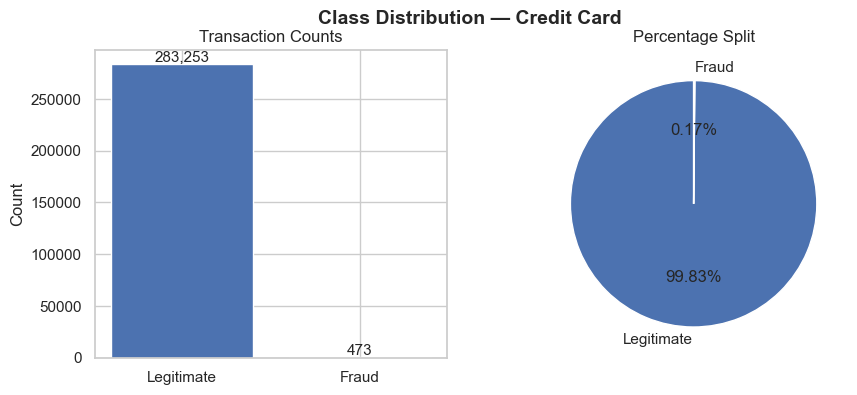

  Saved → ../plots/class_distribution_credit_card.png


In [8]:
# ── Class imbalance ──────────────────────────────────────────────────────────
print('Class distribution:')
print(df_clean['Class'].value_counts())
print(df_clean['Class'].value_counts(normalize=True).mul(100).round(4))

plot_class_distribution(df_clean['Class'], dataset_name='Credit Card')

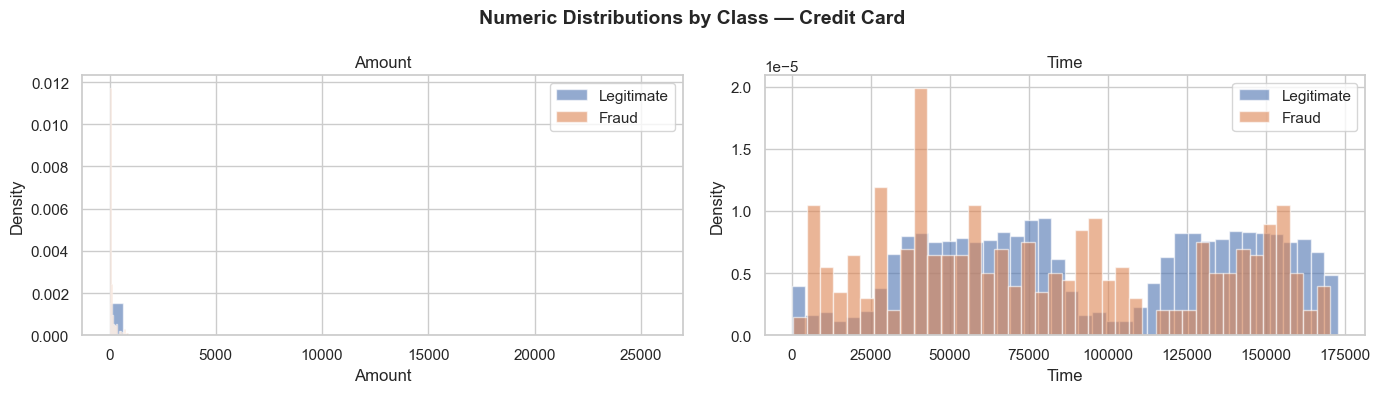

  Saved → ../plots/numeric_distributions_credit_card.png


In [9]:
# ── Amount distribution ──────────────────────────────────────────────────────
plot_numeric_distributions(
    df_clean,
    cols=['Amount', 'Time'],
    target_col='Class',
    dataset_name='Credit Card'
)

In [10]:
# ── Amount statistics by class ────────────────────────────────────────────────
df_clean.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


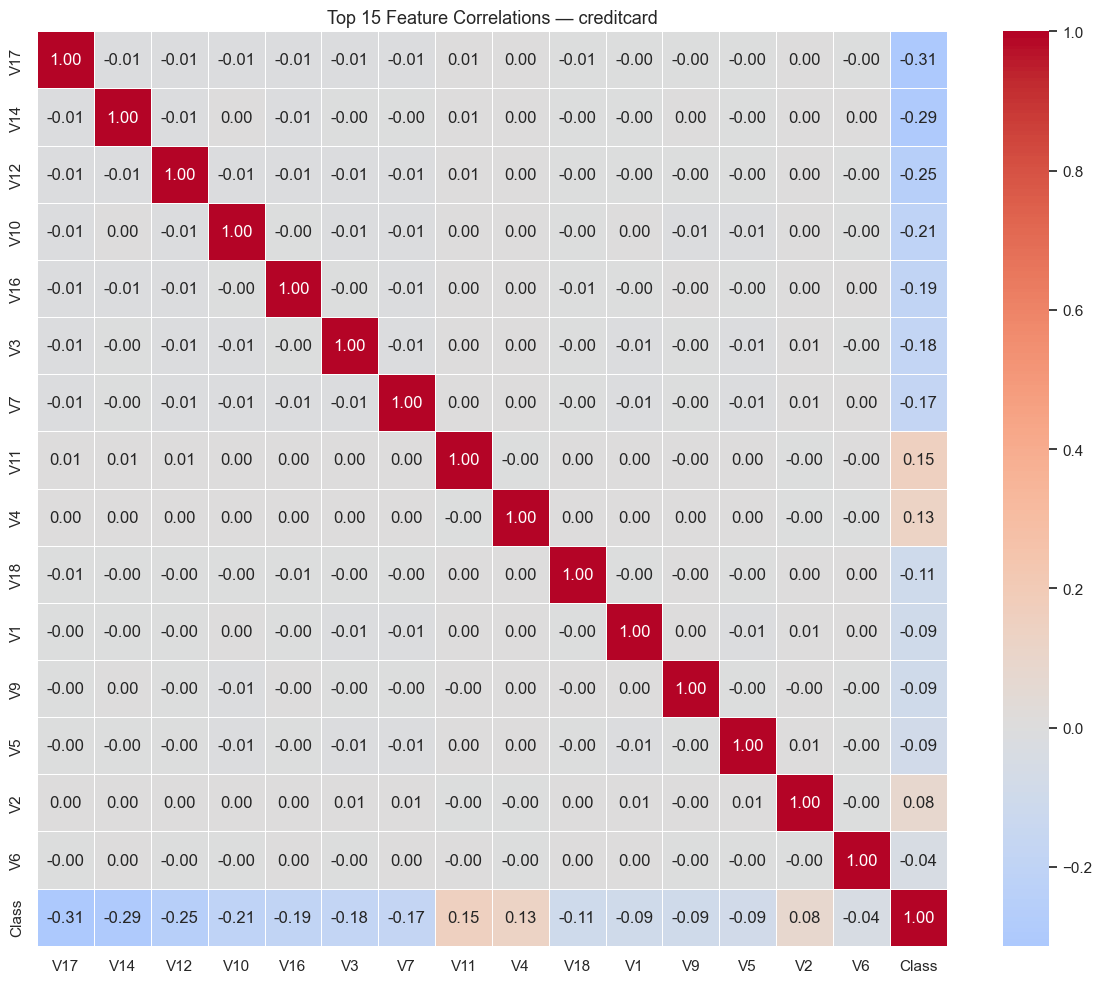

  Saved → ../plots/correlation_heatmap_creditcard.png


In [11]:
# ── Correlation heatmap (top 15 features correlated with Class) ───────────────
plot_correlation_heatmap(df_clean, dataset_name='creditcard', top_n=15)

In [12]:
# Show top correlated features with target
corr_with_target = df_clean.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print('Top 10 features by absolute correlation with Class:')
print(corr_with_target.head(10))

Top 10 features by absolute correlation with Class:
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


### 4. Scaling


In [13]:
# V1-V28 are already PCA-scaled — only Amount and Time need scaling
df_scaled, scaler = encode_and_scale_creditcard(df_clean)

print('Shape after scaling:', df_scaled.shape)

# Verify Amount and Time are scaled
print('\nAmount stats after scaling:')
print(df_scaled['Amount'].describe())

INFO: creditcard after scaling: (283726, 31)


Shape after scaling: (283726, 31)

Amount stats after scaling:
count    2.837260e+05
mean    -8.013847e-19
std      1.000002e+00
min     -3.533268e-01
25%     -3.309625e-01
50%     -2.654671e-01
75%     -4.378088e-02
max      1.022476e+02
Name: Amount, dtype: float64


### 5. Handle Class Imbalance — SMOTE

In [14]:
X_train, X_test, y_train, y_test = split_and_resample(df_scaled, target_col='Class')

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

INFO: Train size: 226980, Test size: 56746
INFO: Class distribution before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64
INFO: Class distribution after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


X_train shape: (453204, 30)
X_test shape: (56746, 30)


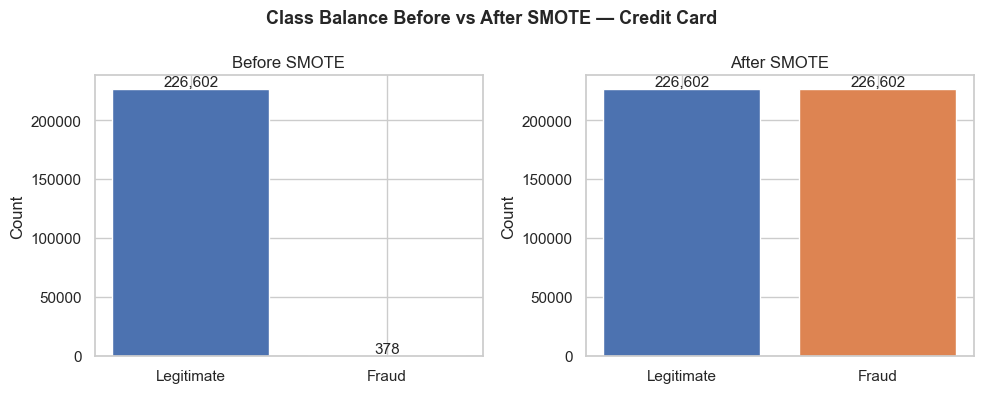

  Saved → ../plots/smote_comparison_credit_card.png


In [15]:
# Compare before/after SMOTE
from sklearn.model_selection import train_test_split
X_raw = df_scaled.drop(columns=['Class'])
y_raw = df_scaled['Class']
_, _, y_train_before, _ = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42)

plot_smote_comparison(y_train_before, y_train, dataset_name='Credit Card')

### 6. Save Processed Data

In [16]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_scaled.to_csv('../data/processed/creditcard_processed.csv', index=False)
print('✅ Saved to data/processed/creditcard_processed.csv')
print('Final shape:', df_scaled.shape)

✅ Saved to data/processed/creditcard_processed.csv
Final shape: (283726, 31)
